# Hyperparameter sweep

Goal:

- Train one model per hyperparameter combination.
- Track every run in the SageMaker MLflow tracking server.
- Export the best model to `s3://<bucket>/trains/models/`.

Grid search tests every combination in a predefined matrix, so each run differs
in exactly one way and the comparison is fair.


## Environment

Install libraries.


In [1]:
%pip install -q -U ultralytics torch torchvision onnx onnxruntime onnxslim mlflow sagemaker-mlflow

Note: you may need to restart the kernel to use updated packages.


Inspect environment.


In [2]:
%matplotlib inline

import os
import sys
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import torch

from sagemaker.core.helper.session_helper import Session

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.tracking import tracking_uri

# local dir
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
RUNS = ROOT / "runs"
MODELS = ROOT / "models"

# create dir
for d in (RAW, PROCESSED, RUNS, MODELS):
    d.mkdir(parents=True, exist_ok=True)

REGION = Session().boto_region_name

# get s3 bucket
env_file = Path.home() / ".sagemaker-yolo.env"
if "BUCKET" not in os.environ and env_file.exists():
    for line in env_file.read_text().splitlines():
        key, _, val = line.partition("=")
        os.environ.setdefault(key.strip(), val.strip())

BUCKET = os.environ["BUCKET"]

# bucket keys
S3_RAW = f"s3://{BUCKET}/data/raw"
S3_SPLIT = f"s3://{BUCKET}/data/split"
S3_MODELS = f"s3://{BUCKET}/trains/models"

# device
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# set tracking server
TRACKING_URI = tracking_uri()
mlflow.set_tracking_uri(TRACKING_URI)

# define experiment
EXPERIMENT = "yolo-plate-detection-sweep"
experiment = mlflow.set_experiment(EXPERIMENT)

# get tracking server instance
server = boto3.client("sagemaker").describe_mlflow_tracking_server(
    TrackingServerName=TRACKING_URI.rsplit("/", 1)[-1]
)
UI_URL = server["TrackingServerUrl"]

# print environment
print("torch     ", torch.__version__)
print("cuda      ", torch.cuda.is_available())
print("device    ", DEVICE)
print("bucket    ", BUCKET)
print("tracking  ", TRACKING_URI)
print("experiment", EXPERIMENT, f"(id {experiment.experiment_id})")
print(f"\nUI: {UI_URL}/#/experiments/{experiment.experiment_id}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


torch      2.13.0+cu130
cuda       False
device     cpu
bucket     sagemaker-yolo-dev-0luf20
tracking   arn:aws:sagemaker:ca-central-1:099139718958:mlflow-tracking-server/sagemaker-yolo-dev
experiment yolo-plate-detection-sweep (id 2)

UI: https://t-p1ukzmxk6vss.ca-central-1.experiments.sagemaker.aws/#/experiments/2


## Split data

Download raw data, split, and store in bucket.


In [3]:
from src.data_loader import build_split, verify_split, write_data_yaml
from src.s3_sync import download, upload

# e.g. 100 for a fast smoke run
# LIMIT = 10
LIMIT = None  # all images

SPLIT_SEED = 0 # split random seed

# download
print(download(S3_RAW, RAW))

# split
print(build_split(RAW, PROCESSED, val_fraction=0.2, limit=LIMIT, seed=SPLIT_SEED))
print(verify_split(PROCESSED))

# store split
print(upload(PROCESSED, S3_SPLIT, delete=True))

# create data config yaml file
names = (RAW / "classes.txt").read_text().split()
data_yaml = write_data_yaml(ROOT / "configs" / "data.yaml", PROCESSED, names)
print(data_yaml.read_text())

{'downloaded': 0, 'skipped': 1113}


{'train': 445, 'val': 111, 'orphan_images': 0, 'orphan_labels': 0}
{'train': 445, 'val': 111}


{'uploaded': 0, 'skipped': 1112, 'removed': 0}
path: /home/sagemaker-user/sagemaker-yolo/data/processed
train: train/images
val: val/images
nc: 1
names: ['car_plate']



## Define sweep

Define combination of training hyperparameters(`GRID`).


In [4]:
from itertools import product

from src.data_loader import build_train_cfg

# create training hyperparameters
base_cfg = build_train_cfg(
    device=DEVICE,
    workers=(os.cpu_count() or 2) if DEVICE != "cpu" else 0,
)
base_cfg["project"] = str(ROOT / base_cfg["project"])

# count images
n_images = sum(len(list((PROCESSED / s / "images").iterdir())) for s in ("train", "val"))
tag = "gpu" if DEVICE != "cpu" else "cpu"

# the axes to sweep; add keys here to widen the grid
SWEEP = {
    "epochs": (10, 20, 30),
}

# define grid
GRID = []
for values in product(*SWEEP.values()):
    overrides = dict(zip(SWEEP.keys(), values))
    suffix = "-".join(f"{k}{v}" for k, v in overrides.items())
    overrides["name"] = f"tune-{tag}-{n_images}img-{base_cfg['imgsz']}px-{suffix}"
    GRID.append(overrides)

# print grid
print(f"experiment {EXPERIMENT}")
print(f"{len(GRID)} runs")
for g in GRID:
    print(" ", g)

experiment yolo-plate-detection-sweep
3 runs
  {'epochs': 10, 'name': 'tune-cpu-556img-640px-epochs10'}
  {'epochs': 20, 'name': 'tune-cpu-556img-640px-epochs20'}
  {'epochs': 30, 'name': 'tune-cpu-556img-640px-epochs30'}


## Run sweep

Loop each grid entry on its own MLflow run.


In [5]:
from src.tracking import run_sweep

results = run_sweep(
    grid=GRID,
    base_cfg=base_cfg,
    data_yaml=data_yaml,
    processed_dir=PROCESSED,
    raw_dir=RAW,
    experiment=EXPERIMENT,
    # keep the mlflow run name and the run directory the same
    run_name=lambda cfg: cfg["name"],
)

summary = pd.DataFrame(results)
summary


[1/3] tune-cpu-556img-640px-epochs10  {'epochs': 10, 'name': 'tune-cpu-556img-640px-epochs10'}


Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Xeon Platinum 8175M CPU @ 2.50GHz)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/sagemaker-user/sagemaker-yolo/configs/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tune-cpu-556img-640px-epochs10, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

MLflow: results logged to arn:aws:sagemaker:ca-central-1:099139718958:mlflow-tracking-server/sagemaker-yolo-dev
MLflow: disable with 'yolo settings mlflow=False'


MLflow: mlflow run still alive, remember to close it using mlflow.end_run()


🏃 View run tune-cpu-556img-640px-epochs30 at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/2/runs/dfe858ba220e4a179988711e0f3952b0
🧪 View experiment at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/2


[3/3] done in 4732s


,name,run_id,save_dir,epochs,mAP50,mAP50-95,elapsed_s
0,tune-cpu-556img-640px-epochs10,75d9a0e0fa314dbd875b3e92530ea176,/home/sagemaker-user/sagemaker-yolo/runs/tune-...,10,0.985073,0.778561,1613
1,tune-cpu-556img-640px-epochs20,f06f4b56c4c148bc883407a9683ad2ad,/home/sagemaker-user/sagemaker-yolo/runs/tune-...,20,0.993886,0.801455,3226
2,tune-cpu-556img-640px-epochs30,dfe858ba220e4a179988711e0f3952b0,/home/sagemaker-user/sagemaker-yolo/runs/tune-...,30,0.980919,0.813581,4732


## Compare runs

Every run in the experiment, side by side.


In [6]:
from src.tracking import compare_runs

compare_runs(EXPERIMENT)

,mlflow.runName,epochs,imgsz,data.train_images,metrics/mAP50B,metrics/mAP50-95B,metrics/precisionB,metrics/recallB
0,tune-cpu-556img-640px-epochs30,30,640,445,0.980919,0.813581,0.974320,0.981254
1,tune-cpu-556img-640px-epochs20,20,640,445,0.993886,0.801455,0.974570,0.991121
2,tune-cpu-556img-640px-epochs10,10,640,445,0.985073,0.778561,0.965789,0.973478
3,tune-cpu-10img-640px-epochs30,30,640,8,0.745000,0.373490,0.003333,1.000000
4,tune-cpu-10img-640px-epochs20,20,640,8,0.995000,0.398867,0.003333,1.000000
5,tune-cpu-10img-640px-epochs10,10,640,8,0.023596,0.009573,0.003333,1.000000
6,tune-cpu-556img-640px-epochs30,30,640,445,0.980919,0.813581,0.974320,0.981254
7,tune-cpu-556img-640px-epochs20,20,640,445,0.993886,0.801455,0.974570,0.991121
8,tune-cpu-556img-640px-epochs10,10,640,445,0.985073,0.778561,0.965789,0.973478
9,tune-cpu-10img-640px-epochs30,30,640,8,0.745000,0.373490,0.003333,1.000000


Plot sweep runs.


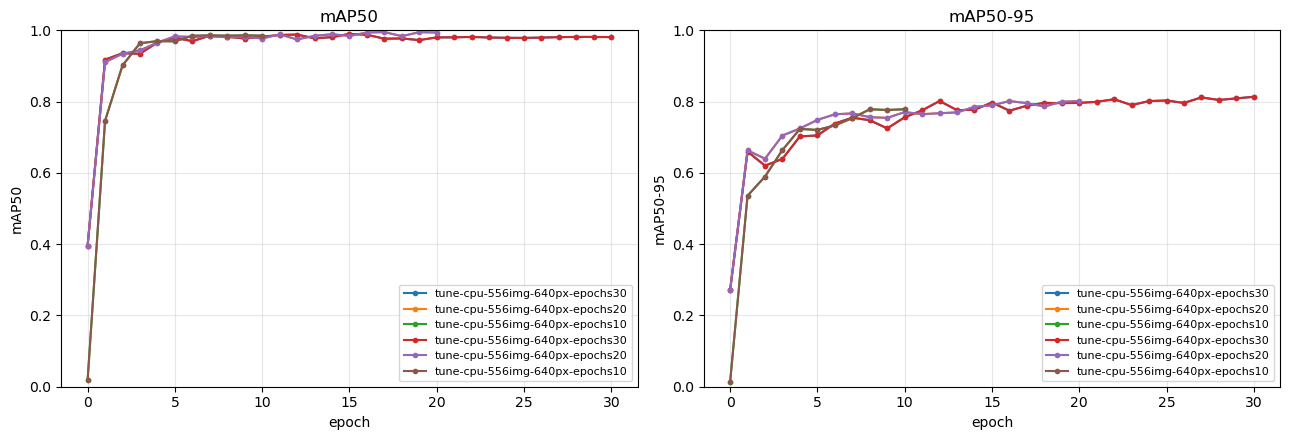

In [7]:
client = mlflow.tracking.MlflowClient()
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# only this sweep's runs; the experiment accumulates older ones
wanted = [g["name"] for g in GRID]
runs = runs[runs["params.name"].isin(wanted)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for _, row in runs.iterrows():
    for ax, metric in zip(axes, ("metrics/mAP50B", "metrics/mAP50-95B")):
        # mlflow does not guarantee ordering, sort by step before plotting
        history = sorted(client.get_metric_history(row["run_id"], metric), key=lambda p: p.step)
        if history:
            ax.plot(
                [p.step for p in history],
                [p.value for p in history],
                marker="o", ms=3, label=row["tags.mlflow.runName"],
            )

for ax, metric in zip(axes, ("mAP50", "mAP50-95")):
    ax.set_xlabel("epoch")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Metrics vs Time: Cost against benefit

More epochs almost always helps a little: **whether the gain justifies the minutes**.

- `gain` and `extra_min` are measured against the cheapest run in the sweep.


In [8]:
cols = {
    "tags.mlflow.runName": "run",
    "params.epochs": "epochs",
    "metrics.metrics/mAP50-95B": "mAP50-95",
    "metrics.elapsed_seconds": "seconds",
}
cost = runs[[c for c in cols if c in runs.columns]].rename(columns=cols)
cost = cost.dropna(subset=["seconds"]).sort_values("seconds")

# baseline is the cheapest run
base = cost.iloc[0]
cost["minutes"] = (cost["seconds"] / 60).round(1)
cost["gain"] = (cost["mAP50-95"] - base["mAP50-95"]).round(4)
cost["extra_min"] = ((cost["seconds"] - base["seconds"]) / 60).round(1)

# minutes spent per 0.01 mAP gained; NaN for the baseline itself
cost["min_per_0.01"] = (cost["extra_min"] / (cost["gain"] * 100)).round(1)

cost[["run", "epochs", "mAP50-95", "minutes", "gain", "extra_min", "min_per_0.01"]]

,run,epochs,mAP50-95,minutes,gain,extra_min,min_per_0.01
8,tune-cpu-556img-640px-epochs10,10,0.778561,26.9,0.0000,0.0,NaN
2,tune-cpu-556img-640px-epochs10,10,0.778561,26.9,0.0000,0.0,NaN
7,tune-cpu-556img-640px-epochs20,20,0.801455,52.8,0.0229,25.9,11.3
1,tune-cpu-556img-640px-epochs20,20,0.801455,53.8,0.0229,26.9,11.7
0,tune-cpu-556img-640px-epochs30,30,0.813581,78.9,0.0350,52.0,14.9
6,tune-cpu-556img-640px-epochs30,30,0.813581,81.2,0.0350,54.4,15.5


## Export the best model

Pick the run with the highest mAP50-95, then export its weights.


In [9]:
# filter metric
METRIC = "mAP50-95"

# filter completed runs
finished = [r for r in results if "error" not in r]
if not finished:
    # error if all fail.
    raise RuntimeError("every run in the sweep failed")

# sort
ranked = sorted(finished, key=lambda r: r[METRIC], reverse=True)
# get best
best_run = ranked[0]

# print best
print(f"compared {len(finished)} of {len(GRID)} runs\n")
for r in ranked:
    print(f"  {r[METRIC]:.4f}  {r['elapsed_s']:>6}s  {r['name']}")

print(f"\nbest      {best_run['name']}")
print(f"mAP50-95  {best_run[METRIC]:.4f}")
print(f"run_id    {best_run['run_id']}")

compared 3 of 3 runs

  0.8136    4732s  tune-cpu-556img-640px-epochs30
  0.8015    3226s  tune-cpu-556img-640px-epochs20
  0.7786    1613s  tune-cpu-556img-640px-epochs10

best      tune-cpu-556img-640px-epochs30
mAP50-95  0.8136
run_id    dfe858ba220e4a179988711e0f3952b0


Export model.


In [10]:
import shutil

from ultralytics import YOLO

# get best save dir
save_dir = Path(best_run["save_dir"])
# construct best model
best = YOLO(str(save_dir / "weights" / "best.pt"))

# imgsz must match training
imgsz = base_cfg["imgsz"]
exported = Path(best.export(format="onnx", imgsz=imgsz, opset=12, simplify=True))

onnx_path = MODELS / f"{best_run['name']}.onnx"
shutil.move(str(exported), onnx_path)

print(onnx_path.name)
print(f"{onnx_path.stat().st_size / 1e6:.1f} MB")

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Xeon Platinum 8175M CPU @ 2.50GHz)


YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs



PyTorch: starting from '/home/sagemaker-user/sagemaker-yolo/runs/tune-cpu-556img-640px-epochs30/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)



ONNX: starting export with onnx 1.22.0 opset 12...


ONNX: slimming with onnxslim 0.1.95...


2026-08-12 19:14:37.686547430 [W:onnxruntime:Default, device_discovery.cc:285 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:94 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


ONNX: export success ✅ 1.4s, saved as '/home/sagemaker-user/sagemaker-yolo/runs/tune-cpu-556img-640px-epochs30/weights/best.onnx' (10.1 MB)



Export complete (1.9s)
Results saved to /home/sagemaker-user/sagemaker-yolo/runs/tune-cpu-556img-640px-epochs30/weights/best.onnx
Predict:         yolo predict task=detect model=/home/sagemaker-user/sagemaker-yolo/runs/tune-cpu-556img-640px-epochs30/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/home/sagemaker-user/sagemaker-yolo/runs/tune-cpu-556img-640px-epochs30/weights/best.onnx imgsz=640 data=/home/sagemaker-user/sagemaker-yolo/configs/data.yaml  
Visualize:       https://netron.app


tune-cpu-556img-640px-epochs30.onnx
10.6 MB


Export metadata file.


In [11]:
import json
from datetime import datetime, timezone

# the graph carries neither class names nor imgsz; the predictor needs both
sidecar = onnx_path.with_suffix(".metadata.json")
sidecar.write_text(json.dumps({
    "imgsz": imgsz,
    "names": [best.names[i] for i in sorted(best.names)],
    "metrics": {
        "mAP50": round(best_run["mAP50"], 4),
        "mAP50-95": round(best_run["mAP50-95"], 4),
    },
    "mlflow": {
        "run_id": best_run["run_id"],
        "experiment": EXPERIMENT,
        "tracking_uri": TRACKING_URI,
    },
    "sweep": {
        "axes": {k: list(v) for k, v in SWEEP.items()},
        "won_with": {k: best_run[k] for k in SWEEP},
        "runs_compared": len(finished),
    },
    "images": n_images,
    "exported_at": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(sidecar.read_text())

{
  "imgsz": 640,
  "names": [
    "car_plate"
  ],
  "metrics": {
    "mAP50": 0.9809,
    "mAP50-95": 0.8136
  },
  "mlflow": {
    "run_id": "dfe858ba220e4a179988711e0f3952b0",
    "experiment": "yolo-plate-detection-sweep",
    "tracking_uri": "arn:aws:sagemaker:ca-central-1:099139718958:mlflow-tracking-server/sagemaker-yolo-dev"
  },
  "sweep": {
    "axes": {
      "epochs": [
        10,
        20,
        30
      ]
    },
    "won_with": {
      "epochs": 30
    },
    "runs_compared": 3
  },
  "images": 556,
  "exported_at": "2026-08-12T19:14:38.336629+00:00"
}


Upload the winner to S3 and attach it to its MLflow run.


In [12]:
from src.s3_sync import list_objects, upload_files

dest = f"{S3_MODELS}/{best_run['name']}"
weights = save_dir / "weights" / "best.pt"

for uri in upload_files([onnx_path, sidecar, weights], dest):
    print(uri)

# reopen the winning run to attach the export
with mlflow.start_run(run_id=best_run["run_id"]):
    mlflow.log_artifact(str(onnx_path), artifact_path="export")
    mlflow.log_artifact(str(sidecar), artifact_path="export")
    mlflow.set_tag("export.s3_uri", dest)
    mlflow.set_tag("sweep.winner", "true")

print()
for key, meta in sorted(list_objects(dest).items()):
    print(f"  {meta['size'] / 1e6:>6.1f} MB  {key.rsplit('/', 1)[-1]}")

print(f"\nrun: {UI_URL}/#/experiments/{experiment.experiment_id}/runs/{best_run['run_id']}")

s3://sagemaker-yolo-dev-0luf20/trains/models/tune-cpu-556img-640px-epochs30/tune-cpu-556img-640px-epochs30.onnx
s3://sagemaker-yolo-dev-0luf20/trains/models/tune-cpu-556img-640px-epochs30/tune-cpu-556img-640px-epochs30.metadata.json
s3://sagemaker-yolo-dev-0luf20/trains/models/tune-cpu-556img-640px-epochs30/best.pt


🏃 View run tune-cpu-556img-640px-epochs30 at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/2/runs/dfe858ba220e4a179988711e0f3952b0
🧪 View experiment at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/2

     5.5 MB  best.pt
     0.0 MB  tune-cpu-556img-640px-epochs30.metadata.json
    10.6 MB  tune-cpu-556img-640px-epochs30.onnx

run: https://t-p1ukzmxk6vss.ca-central-1.experiments.sagemaker.aws/#/experiments/2/runs/dfe858ba220e4a179988711e0f3952b0


## Gate and register the winner

- Same gates as the single-run notebook, applied to the sweep winner.
- Promotion is decided inside `register_model`, so both notebooks compete for one `champion` alias under one rule.


In [13]:
from src.tracking import MIN_MAP, PROMOTION_MARGIN, check_export_parity, register_model

REGISTERED_MODEL = "yolo-plate-detection"

# score the exported onnx against the winning run's .pt metric
parity = check_export_parity(
    onnx_path, data_yaml, reference_map=best_run[METRIC], imgsz=imgsz
)
print(f"parity  onnx {parity['onnx_map']:.4f}  pt {parity['reference_map']:.4f}  "
      f"delta {parity['delta']:.4f}  {'ok' if parity['passed'] else 'FAILED'}")

outcome = register_model(
    best_run["run_id"],
    onnx_path,
    REGISTERED_MODEL,
    min_map=MIN_MAP,
    margin=PROMOTION_MARGIN,
    parity=parity,
)

print(f"\nwinner     {best_run['name']}")
print(f"score      {outcome['score']:.4f}  (floor {MIN_MAP})")
if not outcome["registered"]:
    print(f"REJECTED   {outcome['reason']}")
else:
    print(f"registered version {outcome['version']}")
    if outcome["promoted"]:
        print(f"champion   -> version {outcome['version']}")
    else:
        print(f"champion   stays at version {outcome['champion_version']} "
              f"({outcome['champion_score']:.4f})")
    print(f"\nmodel: {UI_URL}/#/models/{REGISTERED_MODEL}/versions/{outcome['version']}")


WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.


Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Xeon Platinum 8175M CPU @ 2.50GHz)


Loading /home/sagemaker-user/sagemaker-yolo/models/tune-cpu-556img-640px-epochs30.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.28.0 with CPUExecutionProvider


Setting batch=1 input of shape (1, 3, 640, 640)


...

Registered model 'yolo-plate-detection' already exists. Creating a new version of this model...


2026/08/12 19:15:01 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: yolo-plate-detection, version 4


Created version '4' of model 'yolo-plate-detection'.


🏃 View run tune-cpu-556img-640px-epochs30 at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/2/runs/dfe858ba220e4a179988711e0f3952b0
🧪 View experiment at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/2



winner     tune-cpu-556img-640px-epochs30
score      0.8136  (floor 0.7)
registered version 4
champion   -> version 4

model: https://t-p1ukzmxk6vss.ca-central-1.experiments.sagemaker.aws/#/models/yolo-plate-detection/versions/4
